# Experiment: ARX Model Notebook

Objective:
- Rebuild the greenhouse ARX baseline as a reproducible, review-ready notebook.
- Fit ARX(2,2,1) in original engineering units with explicit train/validation/test splits.
- Judge the model by parameter recovery, residual diagnostics, and free-run behavior instead of train-only metrics.


## Plan

- Generate or reload a full-year synthetic dataset.
- Estimate the baseline model with ordinary least squares.
- Compare one-step, 12-step, free-run, and theoretical best deterministic free-run.
- Inspect residual whiteness and model-order search without overriding the project baseline silently.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from arx_pipeline import DataConfig, ModelConfig, SplitConfig, run_pipeline, save_artifact

plt.style.use('seaborn-v0_8-whitegrid')

DATA_CONFIG = DataConfig(
    csv_path=Path('greenhouse_data.csv'),
    generator_script_path=Path('data_generator.py'),
    force_regenerate_from_script=True,
    auto_save_generated_csv=True,
    generated_days=365,
    generated_sampling_seconds=300,
    generated_seed=42,
    generated_start_date='2025-01-01',
)
SPLIT_CONFIG = SplitConfig(train_ratio=0.60, val_ratio=0.20)
MODEL_CONFIG = ModelConfig(na=2, nb=2, nk=1, include_intercept=False)

results = run_pipeline(DATA_CONFIG, SPLIT_CONFIG, MODEL_CONFIG)
save_artifact(results)

overview = results['dataset_overview']
pd.Series({
    'data_source': results['data_source'],
    'rows': overview['rows'],
    'timestamp_start': overview['timestamp_start'],
    'timestamp_end': overview['timestamp_end'],
    'months_present': overview['months_present'],
    'seasons_present': overview['seasons_present'],
    'rank_x_train': overview['rank_x_train'],
    'n_params': overview['n_params'],
    'condition_number_xtx': round(overview['condition_number_xtx'], 2),
})


data_source                         GENERATED:data_generator.py
rows                                                     105120
timestamp_start                             2025-01-01 00:00:00
timestamp_end                               2025-12-31 23:55:00
months_present          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
seasons_present                [autumn, spring, summer, winter]
rank_x_train                                                 14
n_params                                                     14
condition_number_xtx                                56303331.05
dtype: object

## Dataset And Operating Regime

The dataset now spans all 12 months. That fixes the earlier problem where the notebook only judged January data and overclaimed generality.


In [2]:
behavior_df = pd.DataFrame([
    results['train']['behavior'],
    results['val']['behavior'],
    results['test']['behavior'],
])
behavior_df


,label,rows,timestamp_start,timestamp_end,months_present,seasons_present,drip_on_pct,drip_switches,mist_on_pct,mist_switches,fan_on_pct,fan_switches,below_sp_pct,inside_sp_pct,above_sp_pct
0,Train,63072,2025-01-01 00:00:00,2025-08-07 23:55:00,"[1, 2, 3, 4, 5, 6, 7, 8]","[spring, summer, winter]",22.95,7546,7.81,4760,17.46,7865,23.30,76.13,0.57
1,Validation,21024,2025-08-08 00:00:00,2025-10-19 23:55:00,"[8, 9, 10]","[autumn, summer]",23.47,2558,9.77,1970,19.34,2817,23.84,75.75,0.41
2,Test,21024,2025-10-20 00:00:00,2025-12-31 23:55:00,"[10, 11, 12]","[autumn, winter]",21.68,2429,6.25,1292,12.75,2085,21.70,77.61,0.69


## Metrics

Read the validation and test free-run columns first. For synthetic data, also compare them against the theoretical deterministic ceiling computed from the true generator parameters.


In [3]:
metric_rows = []
for key in ['train', 'val', 'test']:
    evaluation = results[key]
    row = {
        'slice': evaluation['name'],
        'FIT_1step': evaluation['metrics_1step']['FIT'],
        'FIT_12step': evaluation['metrics_n_step']['FIT'],
        'FIT_sim': evaluation['metrics_sim']['FIT'],
        'RMSE_1step': evaluation['metrics_1step']['RMSE'],
        'RMSE_sim': evaluation['metrics_sim']['RMSE'],
        'Theo_FIT_sim': evaluation.get('theoretical_max_free_run', {}).get('FIT'),
        'Theo_RMSE_sim': evaluation.get('theoretical_max_free_run', {}).get('RMSE'),
    }
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
metrics_df.round(4)


,slice,FIT_1step,FIT_12step,FIT_sim,RMSE_1step,RMSE_sim,Theo_FIT_sim,Theo_RMSE_sim
0,Train,92.5471,76.4447,49.5463,0.2499,1.6920,49.0595,1.7083
1,Validation,91.6406,73.1094,42.9588,0.2510,1.7124,42.2497,1.7337
2,Test,91.3491,72.6736,43.8749,0.2520,1.6347,43.2691,1.6524


## Parameter Recovery

A baseline ARX used for control must recover the direction of effect correctly. Wrong signs are a much bigger problem than a pretty train RMSE.


In [4]:
params_df = pd.DataFrame(results['parameter_summary'])[[
    'name',
    'estimate',
    'true_value',
    'delta_vs_true',
    'sign_ok',
    'ci95_low',
    'ci95_high',
]]
params_df.round(6)


,name,estimate,true_value,delta_vs_true,sign_ok,ci95_low,ci95_high
0,a1,0.963098,0.96500,-0.001902,True,0.959824,0.966371
1,a2,0.026738,0.02500,0.001738,True,0.023358,0.030118
2,b_Temperature_1,-0.007410,-0.00800,0.000590,True,-0.012403,-0.002416
3,b_Temperature_2,-0.003922,-0.00400,0.000078,True,-0.008808,0.000964
4,b_Humidity_1,0.002567,0.00250,0.000067,True,0.000929,0.004206
5,b_Humidity_2,0.001029,0.00120,-0.000171,True,-0.000588,0.002646
6,b_Light_1,-0.000132,-0.00022,0.000088,True,-0.000270,0.000005
7,b_Light_2,-0.000194,-0.00010,-0.000094,True,-0.000334,-0.000055
8,b_Drip_1,1.251167,1.25000,0.001167,True,1.244526,1.257809
9,b_Drip_2,1.851585,1.85000,0.001585,True,1.840899,1.862271


In [5]:
sign_ok_count = int(params_df['sign_ok'].sum())
print(f'Sign-correct parameters: {sign_ok_count} / {len(params_df)}')
pd.DataFrame(results['ar_roots']).round(6)


Sign-correct parameters: 14 / 14


,root_index,real,imag,magnitude
0,1,0.990103,0.0,0.990103
1,2,-0.027005,0.0,0.027005


## Prediction And Free-Run Plots

The key question is whether the deterministic simulation stays close to reality for long horizons, not whether one-step prediction looks clean.


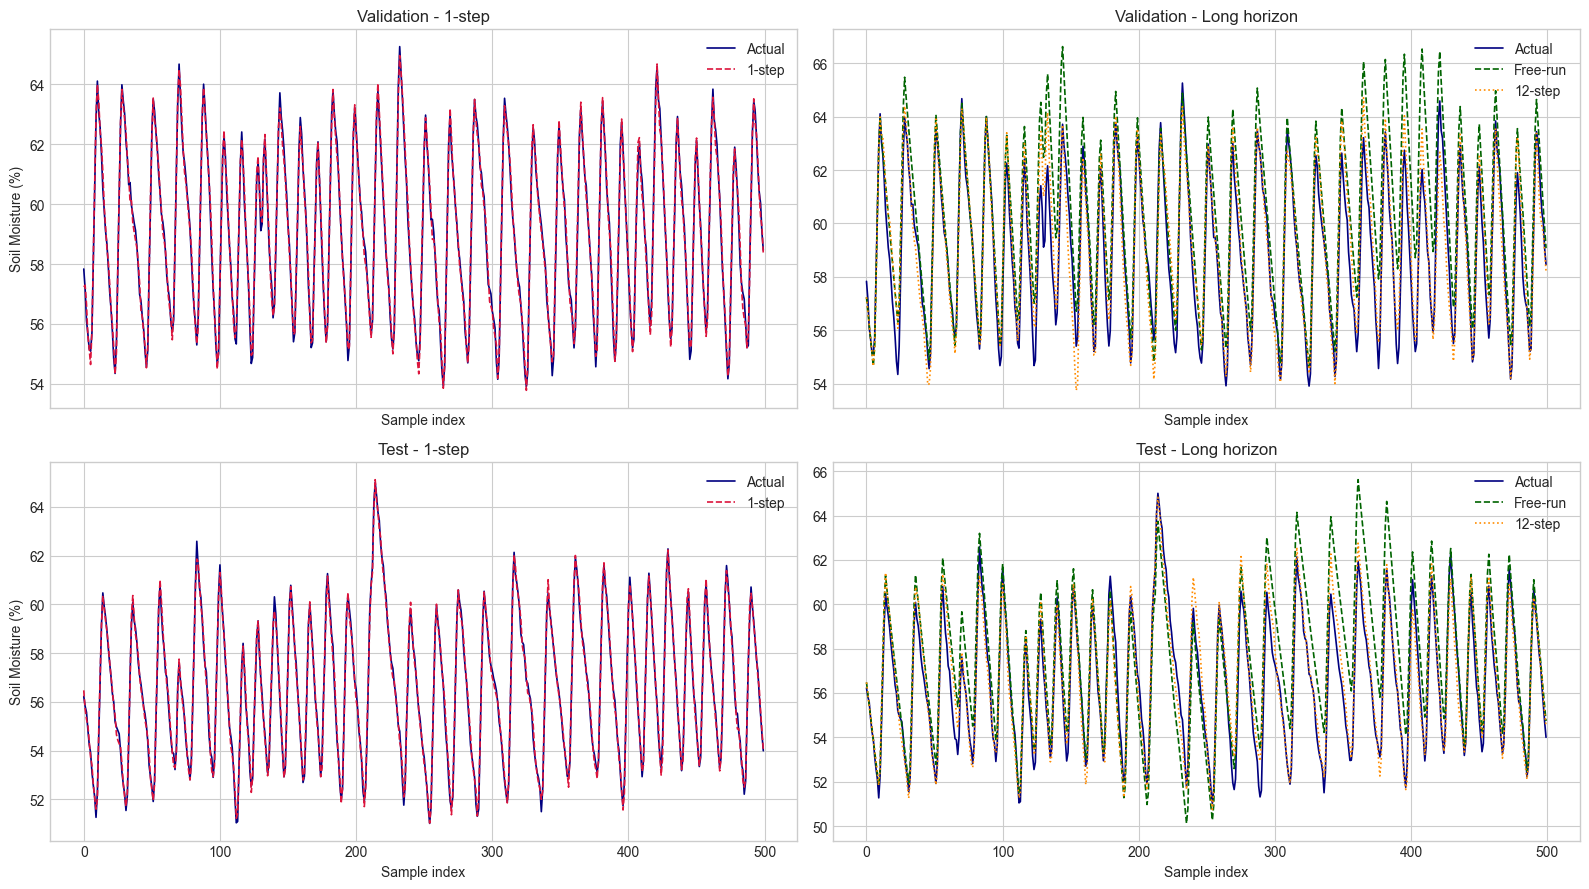

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex='col')

for row_idx, key in enumerate(['val', 'test']):
    evaluation = results[key]
    arrays = evaluation['arrays']
    n_plot_1 = min(500, len(arrays['y_true_1step']))
    n_plot_sim = min(500, len(arrays['y_true_sim']))

    axes[row_idx, 0].plot(arrays['y_true_1step'][:n_plot_1], label='Actual', color='navy', linewidth=1.2)
    axes[row_idx, 0].plot(arrays['y_pred_1step'][:n_plot_1], label='1-step', color='crimson', linestyle='--', linewidth=1.2)
    axes[row_idx, 0].set_title(f"{evaluation['name']} - 1-step")
    axes[row_idx, 0].set_ylabel('Soil Moisture (%)')

    axes[row_idx, 1].plot(arrays['y_true_sim'][:n_plot_sim], label='Actual', color='navy', linewidth=1.2)
    axes[row_idx, 1].plot(arrays['y_pred_sim'][:n_plot_sim], label='Free-run', color='darkgreen', linestyle='--', linewidth=1.2)
    axes[row_idx, 1].plot(arrays['y_pred_n_step'][:n_plot_sim], label='12-step', color='darkorange', linestyle=':', linewidth=1.2)
    axes[row_idx, 1].set_title(f"{evaluation['name']} - Long horizon")

for ax in axes.flat:
    ax.legend()
    ax.set_xlabel('Sample index')

plt.tight_layout()
plt.show()


## Residual Diagnostics

Residuals should be centered, approximately normal, and uncorrelated with past inputs. This is where the previous notebook was incomplete because Ljung-Box was skipped.


In [7]:
diag_rows = []
for key in ['val', 'test']:
    diag = results[key]['residual_diagnostics']
    diag_rows.append({
        'slice': results[key]['name'],
        'mean': diag['mean'],
        'std': diag['std'],
        'shapiro_p': diag['normality']['shapiro_pvalue'],
        'dagostino_p': diag['normality']['dagostino_pvalue'],
        'ljung_box_pass': diag['ljung_box']['passes_all_lags'],
        'failed_lags': diag['ljung_box']['failed_lags'],
    })

diag_df = pd.DataFrame(diag_rows)
diag_df


,slice,mean,std,shapiro_p,dagostino_p,ljung_box_pass,failed_lags
0,Validation,0.001619,0.250953,0.202405,0.411814,True,[]
1,Test,0.000488,0.251971,0.725888,0.114067,True,[]


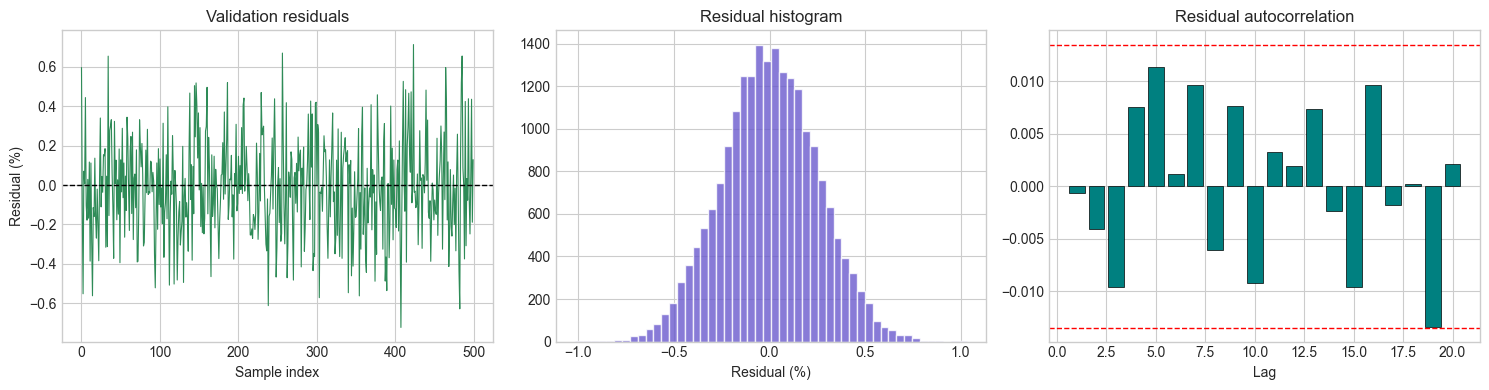

In [8]:
val_arrays = results['val']['arrays']
val_residuals = val_arrays['y_true_1step'] - val_arrays['y_pred_1step']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(val_residuals[:500], color='seagreen', linewidth=0.8)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Validation residuals')
axes[0].set_xlabel('Sample index')
axes[0].set_ylabel('Residual (%)')

axes[1].hist(val_residuals, bins=50, color='slateblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Residual histogram')
axes[1].set_xlabel('Residual (%)')

acf_values = [pd.Series(val_residuals[:-lag]).corr(pd.Series(val_residuals[lag:])) for lag in range(1, 21)]
axes[2].bar(range(1, 21), acf_values, color='teal', edgecolor='black', linewidth=0.5)
axes[2].axhline(1.96 / len(val_residuals) ** 0.5, color='red', linestyle='--', linewidth=1.0)
axes[2].axhline(-1.96 / len(val_residuals) ** 0.5, color='red', linestyle='--', linewidth=1.0)
axes[2].set_title('Residual autocorrelation')
axes[2].set_xlabel('Lag')

plt.tight_layout()
plt.show()


## Model-Order Search

This search is diagnostic only. For synthetic data with known truth, a larger order may beat free-run RMSE by absorbing process noise rather than matching the real plant structure.


In [9]:
sel_df = results['model_selection'].copy()
sel_df.head(10).round(4)


,na,nb,nk,n_params,RMSE_1step,FIT_1step,R2_1step,AIC_1step,BIC_1step,RMSE_sim,FIT_sim,R2_sim
0,3,1,1,9,0.4102,86.3359,0.9813,-37443.8834,-37372.3039,1.5035,49.9185,0.7492
1,2,1,1,8,0.4209,85.9812,0.9803,-36371.2618,-36307.6352,1.6094,46.3905,0.7126
2,1,2,1,13,0.2514,91.6262,0.9930,-58026.2945,-57922.9013,1.6211,46.0003,0.7084
3,3,1,2,9,0.4516,84.9589,0.9774,-33407.2784,-33335.6989,1.7004,43.3621,0.6792
4,1,3,1,19,0.2511,91.6375,0.9930,-58066.9289,-57915.8166,1.7079,43.1125,0.6764
5,3,2,1,15,0.2509,91.6417,0.9930,-58096.4441,-57977.1449,1.7116,42.9892,0.6750
6,2,2,1,14,0.2510,91.6406,0.9930,-58096.5147,-57985.1682,1.7124,42.9588,0.6746
7,2,3,1,20,0.2510,91.6406,0.9930,-58080.5684,-57921.5029,1.7201,42.7066,0.6717
8,3,3,1,21,0.2510,91.6406,0.9930,-58078.5459,-57911.5271,1.7216,42.6546,0.6712
9,2,1,2,8,0.4542,84.8712,0.9771,-33167.4943,-33103.8677,1.7320,42.3082,0.6672


In [10]:
best = sel_df.iloc[0]
baseline = sel_df[(sel_df['na'] == 2) & (sel_df['nb'] == 2) & (sel_df['nk'] == 1)].iloc[0]

print(
    f"Best free-run model on validation: ARX({int(best.na)}, {int(best.nb)}, {int(best.nk)}) "
    f"| FIT_sim={best.FIT_sim:.3f} | RMSE_sim={best.RMSE_sim:.4f}"
)
print(
    f"Baseline ARX(2,2,1): FIT_sim={baseline.FIT_sim:.3f} | RMSE_sim={baseline.RMSE_sim:.4f}"
)
print(
    'Interpretation: keep ARX(2,2,1) as the baseline when the goal is structure recovery and control-oriented interpretability.'
)


Best free-run model on validation: ARX(3, 1, 1) | FIT_sim=49.919 | RMSE_sim=1.5035
Baseline ARX(2,2,1): FIT_sim=42.959 | RMSE_sim=1.7124
Interpretation: keep ARX(2,2,1) as the baseline when the goal is structure recovery and control-oriented interpretability.


## Conclusion

- The notebook now evaluates a full-year dataset instead of a single-month slice.
- ARX(2,2,1) is estimated with OLS in original units and exported to `arx_model.json`.
- Parameter signs, residual whiteness, and theoretical free-run ceiling are reported explicitly.
- Use validation/test free-run plus parameter recovery as the main scoring criteria when presenting the project.
